# exp-confusion-specialist-01 — 다중 혼동 암종군 soft specialist

## 목적
08-spec Logistic Regression의 반복 혼동을 26-class 전체 모델 안에서 보수적으로 보정한다. 각 outer fold의 train 행만 사용해 inner-OOF 혼동쌍을 자동 선택하고, 선택된 각 쌍의 binary LR specialist가 두 클래스 확률의 **내부 비율만** soft gate로 조정한다.

### 실행 전 고정 규칙
- Primary/Specialist: Logistic Regression (`lbfgs`, `C=0.07`, `max_iter=2000`, `class_weight='balanced'`)
- outer CV: Stratified 5-fold, seed 42 탐색
- 혼동쌍 선택: outer-train 내부 Stratified 3-fold OOF, 상위 비중복 3쌍
- Gate: `alpha=0.30`, pair probability mass `>=0.20`, pair 내부 최대 확률 `<=0.85`
- 확률 보존: 선택 pair의 확률합 및 나머지 24개 클래스 확률은 변경하지 않음
- 누수 방지: test는 읽지 않으며, pair 선택·피처 선택·모델 학습 모두 fold-train only
- 채택 기준: 전체 Macro F1 개선뿐 아니라 선택 군의 pair F1과 양방향 혼동도 악화되지 않아야 함


In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'exp_confusion_specialist_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'exp_confusion_specialist_runner.py'
        if direct.exists():
            return path
        if project.exists():
            return project.parent.parent
    raise FileNotFoundError('confusion-specialist runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'exp_confusion_specialist_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RUN_ID = 'exp-confusion-specialist-01'
SEED = 42
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'result_dir': RESULT_DIR, 'seed': SEED, 'max_pairs': 3, 'alpha': 0.30})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/exp_confusion_specialist_runner.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/result'), 'seed': 42, 'max_pairs': 3, 'alpha': 0.3}


In [2]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--seed', str(SEED), '--run-id', RUN_ID]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    assert process.stdout is not None
    tail = []
    for line in process.stdout:
        print(line, end='')
        tail = (tail + [line])[-80:]
    return_code = process.wait()
    if return_code:
        raise RuntimeError(f'confusion-specialist runner failed (exit={return_code}). Last output:\n' + ''.join(tail))



row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 372.36it/s]

confusion-specialist | seed 42:   0%|          | 0/5 [00:00<?, ?fold/s]
confusion-specialist | seed 42:  20%|██        | 1/5 [00:21<01:25, 21.26s/fold]
confusion-specialist | seed 42:  40%|████      | 2/5 [00:42<01:02, 20.97s/fold]
confusion-specialist | seed 42:  60%|██████    | 3/5 [01:01<00:40, 20.48s/fold]
confusion-specialist | seed 42:  80%|████████  | 4/5 [01:23<00:20, 20.83s/fold]
confusion-specialist | seed 42: 100%|██████████| 5/5 [01:43<00:00, 20.77s/fold]
confusion-specialist | seed 42: 100%|██████████| 5/5 [01:43<00:00, 20.79s/fold]
[
  {
    "experiment_id":"exp-confusion-specialist-01",
    "variant":"lr08_primary",
    "seed":42,
    "oof_macro_f1":0.4825927952,
    "delta_vs_baseline":0.0,
    "feature_count_mean":8175.2,
    "runtime_seconds":103.990442125,
    "convergence_warning_count":0,
    "leakage_check":true,
    "nan_as_mutation_count":0,
    "inner_splits":3,
    "max_pairs":3,


,experiment_id,variant,seed,oof_macro_f1,delta_vs_baseline,feature_count_mean,runtime_seconds,convergence_warning_count,leakage_check,nan_as_mutation_count,inner_splits,max_pairs,alpha,min_pair_mass,max_pair_confidence
0,exp-confusion-specialist-01,lr08_primary,42,0.482593,0.000000,8175.2,103.990442,0,True,0,3,3,0.3,0.2,0.85
1,exp-confusion-specialist-01,multi_pair_soft_specialist,42,0.481587,-0.001006,8175.2,103.990458,0,True,0,3,3,0.3,0.2,0.85


,fold,baseline_fold_macro_f1,specialist_fold_macro_f1,selected_pair_count,gate_applied_valid_rows,feature_count,selected_pairs
0,1,0.472420,0.471731,3,346,8134,"[""KIPAN__KIRC"", ""GBMLGG__LGG"", ""BRCA__OV""]"
1,2,0.486886,0.485853,3,353,8177,"[""KIPAN__KIRC"", ""GBMLGG__LGG"", ""BRCA__OV""]"
2,3,0.468533,0.466212,3,346,8143,"[""KIPAN__KIRC"", ""GBMLGG__LGG"", ""BRCA__OV""]"
3,4,0.476903,0.476019,3,352,8223,"[""KIPAN__KIRC"", ""GBMLGG__LGG"", ""BRCA__OV""]"
4,5,0.504069,0.503884,3,345,8199,"[""KIPAN__KIRC"", ""GBMLGG__LGG"", ""BRCA__OV""]"


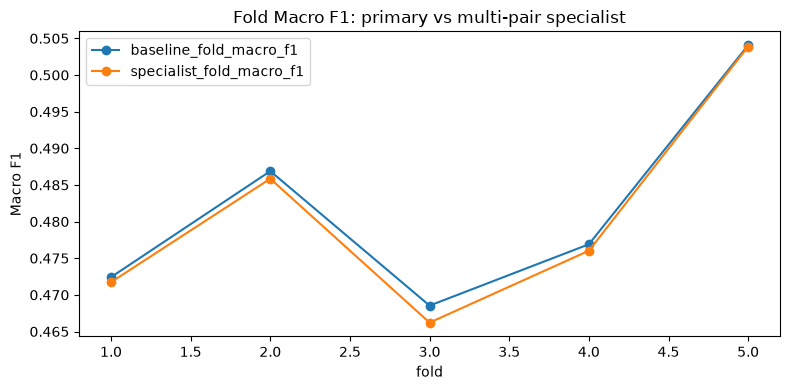

,fold,left,right,inner_oof_two_way_confusion,gate_applied_valid_rows,baseline_pair_macro_f1,specialist_pair_macro_f1,baseline_left_to_right,specialist_left_to_right,baseline_right_to_left,specialist_right_to_left,left_index,right_index,pair,pair_f1_delta
0,1,KIPAN,KIRC,252,165,0.229870,0.222056,50,50,31,32,8,9,KIPAN ↔ KIRC,-0.007815
1,1,GBMLGG,LGG,178,89,0.440123,0.440123,36,36,9,9,6,11,GBMLGG ↔ LGG,0.000000
2,1,BRCA,OV,94,92,0.619048,0.619048,15,15,3,3,2,15,BRCA ↔ OV,0.000000
3,2,KIPAN,KIRC,263,168,0.246668,0.232959,53,52,33,35,8,9,KIPAN ↔ KIRC,-0.013709
4,2,GBMLGG,LGG,179,88,0.463170,0.471187,36,36,11,10,6,11,GBMLGG ↔ LGG,0.008017
5,2,BRCA,OV,89,97,0.490813,0.484793,32,33,2,2,2,15,BRCA ↔ OV,-0.006020
6,3,KIPAN,KIRC,276,159,0.264062,0.248677,44,44,36,38,8,9,KIPAN ↔ KIRC,-0.015385
7,3,GBMLGG,LGG,178,92,0.451687,0.445489,33,32,14,15,6,11,GBMLGG ↔ LGG,-0.006198
8,3,BRCA,OV,96,95,0.585293,0.581963,23,23,2,2,2,15,BRCA ↔ OV,-0.003330
9,4,KIPAN,KIRC,268,145,0.222685,0.222685,46,46,34,34,8,9,KIPAN ↔ KIRC,0.000000


,pair,inner_confusion,pair_f1_delta,gate_rows
2,KIPAN ↔ KIRC,267.8,-0.007382,802
1,GBMLGG ↔ LGG,178.0,0.000364,457
0,BRCA ↔ OV,95.8,-0.003163,483


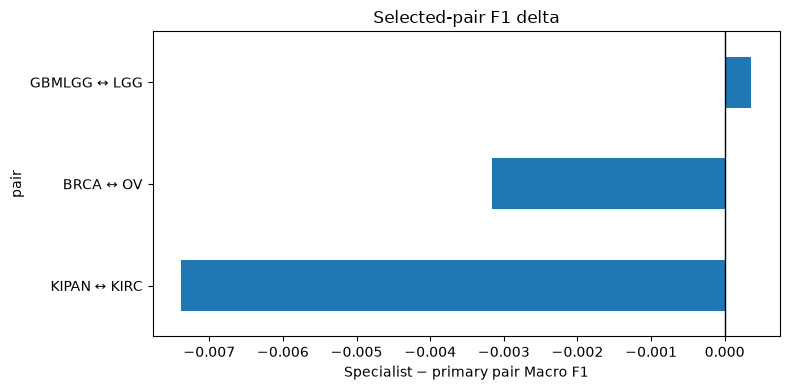

In [3]:
summary = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_summary.csv')
folds = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_folds.csv')
pairs = pd.read_csv(RESULT_DIR / f'{RUN_ID}_seed{SEED}_pairs.csv')
assert summary.leakage_check.all() and summary.nan_as_mutation_count.eq(0).all()
display(summary.sort_values('oof_macro_f1', ascending=False))
display(folds)

ax = folds.set_index('fold')[['baseline_fold_macro_f1', 'specialist_fold_macro_f1']].plot(marker='o', figsize=(8, 4), title='Fold Macro F1: primary vs multi-pair specialist')
ax.set_ylabel('Macro F1'); plt.tight_layout()
plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_fold_macro_f1.png', dpi=160)
plt.show()

if not pairs.empty:
    pairs['pair'] = pairs['left'] + ' ↔ ' + pairs['right']
    pairs['pair_f1_delta'] = pairs['specialist_pair_macro_f1'] - pairs['baseline_pair_macro_f1']
    display(pairs.sort_values(['fold', 'inner_oof_two_way_confusion'], ascending=[True, False]))
    pair_summary = pairs.groupby('pair', as_index=False).agg(inner_confusion=('inner_oof_two_way_confusion', 'mean'), pair_f1_delta=('pair_f1_delta', 'mean'), gate_rows=('gate_applied_valid_rows', 'sum'))
    display(pair_summary.sort_values('inner_confusion', ascending=False))
    ax = pair_summary.set_index('pair')['pair_f1_delta'].sort_values().plot.barh(figsize=(8, 4), title='Selected-pair F1 delta')
    ax.axvline(0, color='black', linewidth=1); ax.set_xlabel('Specialist − primary pair Macro F1'); plt.tight_layout()
    plt.savefig(RESULT_DIR / f'{RUN_ID}_seed{SEED}_pair_f1_delta.png', dpi=160)
    plt.show()
